# Importing list

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Load

In [55]:
df=pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\Mini Project\Improving Employee Retention by Predicting Employee Attrition Using Machine Learning\tahap01\retention.csv", sep=";")

In [56]:
df.sample(5)

,Username,EnterpriseID,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,...,NomorHP,Email,TingkatPendidikan,PernahBekerja,IkutProgramLOP,AlasanResign,TanggalLahir,TanggalHiring,TanggalPenilaianKaryawan,TanggalResign
91,somberJerky8,100992,Lainnya,Pria,Outsource,Scrum Master,Freshgraduate_program,Kurang,Jakarta Barat,CareerBuilder,...,+6285581609xxx,somberJerky8901@icloud.com,Magister,1,NaN,masih_bekerja,1959-08-19,2011-11-07,2019-2-14,-
77,culturedOrange6,101163,Menikah,Wanita,FullTime,Software Engineer (Back End),Senior_level,Sangat_bagus,Jakarta Pusat,LinkedIn,...,+6283359623xxx,culturedOrange6330@yahoo.com,Magister,1,NaN,masih_bekerja,1976-08-25,2016-05-11,2020-1-21,-
230,outlyingCamel2,106467,Belum_menikah,Wanita,FullTime,Software Engineer (Back End),Mid_level,Biasa,Jakarta Timur,Employee_Referral,...,+6281380903xxx,outlyingCamel2337@icloud.com,Sarjana,1,NaN,kejelasan_karir,1981-10-11,2015-2-16,2020-2-14,2018-04-01
257,puzzledUnicorn3,101135,Menikah,Wanita,FullTime,Digital Product Manager,Freshgraduate_program,Sangat_kurang,Jakarta Timur,LinkedIn,...,+6289989448xxx,puzzledUnicorn3199@outlook.com,Sarjana,1,NaN,NaN,1976-12-26,2013-07-08,2017-06-10,-
161,needfulZebra5,111703,Menikah,Pria,FullTime,Software Engineer (Back End),Freshgraduate_program,Sangat_bagus,Jakarta Pusat,Diversity_Job_Fair,...,+6285507346xxx,needfulZebra5962@gmail.com,Sarjana,1,NaN,tidak_bisa_remote,1983-06-14,2013-2-18,2018-02-12,2015-4-15


# EDA

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Username                            287 non-null    str    
 1   EnterpriseID                        287 non-null    int64  
 2   StatusPernikahan                    287 non-null    str    
 3   JenisKelamin                        287 non-null    str    
 4   StatusKepegawaian                   287 non-null    str    
 5   Pekerjaan                           287 non-null    str    
 6   JenjangKarir                        287 non-null    str    
 7   PerformancePegawai                  287 non-null    str    
 8   AsalDaerah                          287 non-null    str    
 9   HiringPlatform                      287 non-null    str    
 10  SkorSurveyEngagement                287 non-null    int64  
 11  SkorKepuasanPegawai                 282 non-null    floa

## Missing

In [58]:
print("=== MISSING / NULL VALUES ===")
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
display(null_summary[null_summary['Null Count'] > 0] if df.isnull().sum().sum() > 0 else "No missing values found!")

=== MISSING / NULL VALUES ===


,Null Count,Null Percentage (%)
SkorKepuasanPegawai,5,1.742160
JumlahKeikutsertaanProjek,3,1.045296
JumlahKeterlambatanSebulanTerakhir,1,0.348432
JumlahKetidakhadiran,6,2.090592
IkutProgramLOP,258,89.895470
AlasanResign,66,22.996516


In [59]:
cols=["SkorKepuasanPegawai",
      "JumlahKeikutsertaanProjek",
      "JumlahKeterlambatanSebulanTerakhir",
      "JumlahKetidakhadiran",
      "IkutProgramLOP"]

df[cols].describe().round(2)

,SkorKepuasanPegawai,JumlahKeikutsertaanProjek,JumlahKeterlambatanSebulanTerakhir,JumlahKetidakhadiran,IkutProgramLOP
count,282.00,284.00,286.00,281.00,29.00
mean,3.90,1.18,0.41,10.45,0.52
std,0.91,2.29,1.28,6.90,0.51
min,1.00,0.00,0.00,1.00,0.00
25%,3.00,0.00,0.00,5.00,0.00
50%,4.00,0.00,0.00,10.00,1.00
75%,5.00,0.00,0.00,15.00,1.00
max,5.00,8.00,6.00,55.00,1.00


### Handling

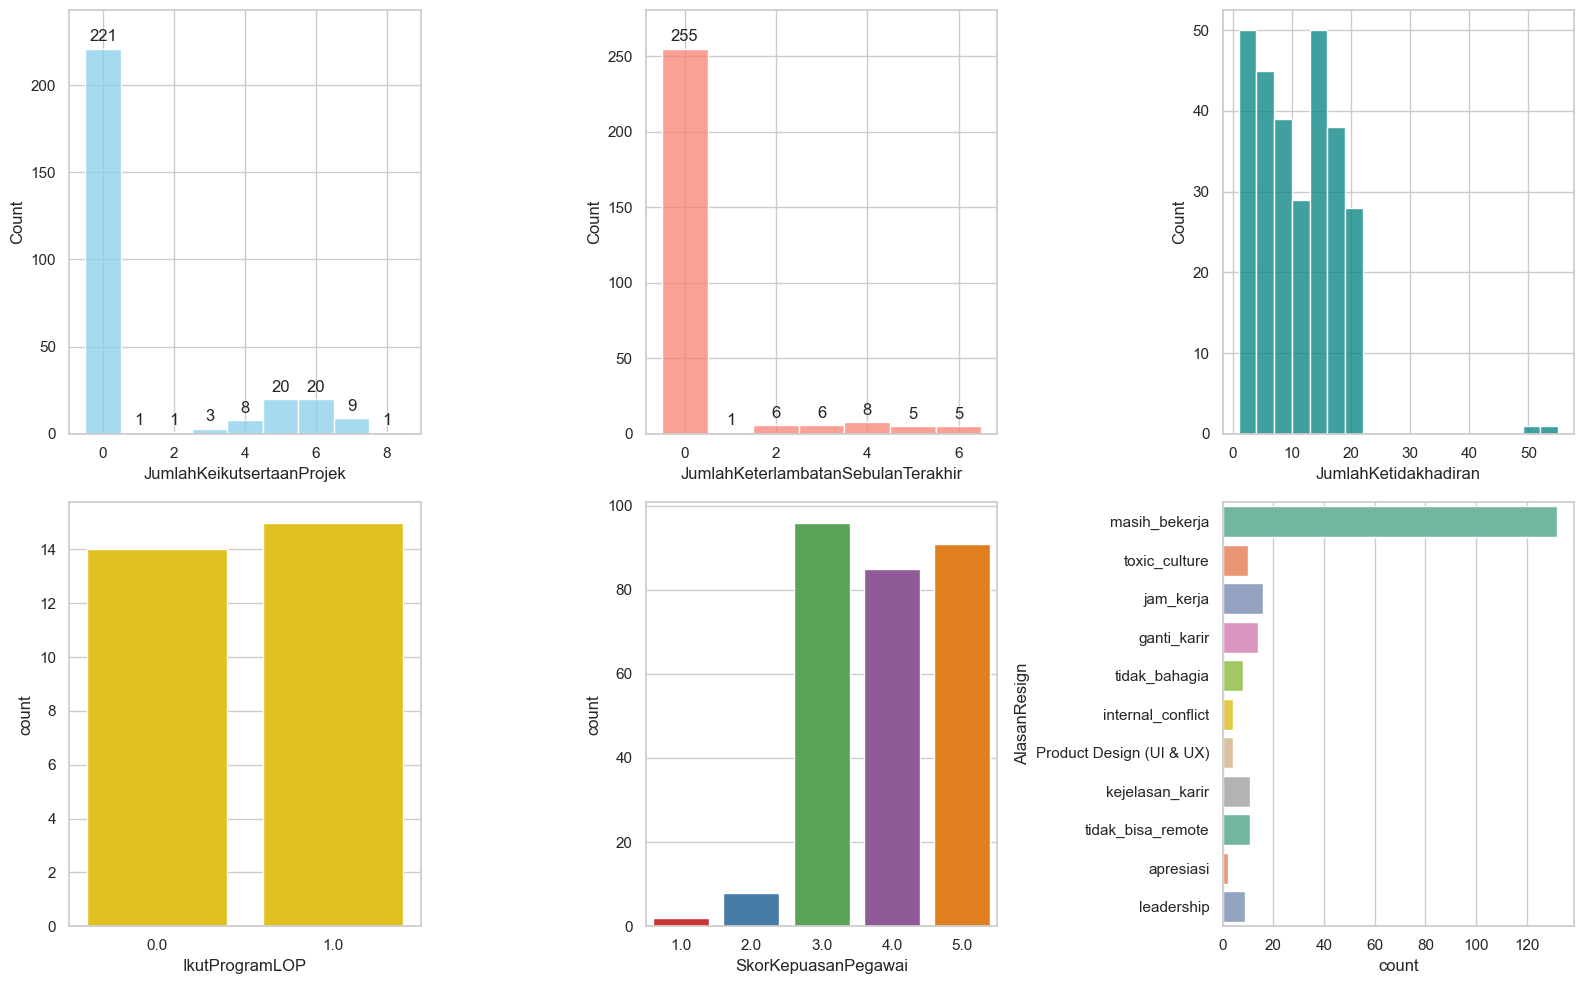

In [60]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

#Numerical Plots (Histograms with KDE)
sns.histplot(df["JumlahKeikutsertaanProjek"], ax=axes[0, 0], color='skyblue', discrete=True)
#Add total counts on top of each bar
axes[0, 0].bar_label(axes[0, 0].containers[0], padding=3)
#Add extra padding at the top so labels don't get cut off
axes[0, 0].margins(y=0.1)

sns.histplot(df["JumlahKeterlambatanSebulanTerakhir"], ax=axes[0, 1], color='salmon', discrete=True)
axes[0, 1].bar_label(axes[0, 1].containers[0], padding=3)
axes[0, 1].margins(y=0.1)

sns.histplot(df["JumlahKetidakhadiran"], ax=axes[0, 2], color='teal')

# Categorical Distributions
sns.countplot(x="IkutProgramLOP", data=df, ax=axes[1, 0], color='gold', legend=False)

sns.countplot(
    x="SkorKepuasanPegawai",
    data=df,
    ax=axes[1, 1],
    hue="SkorKepuasanPegawai",
    palette="Set1",
    legend=False,  # Hides unnecessary legend created by hue
)

sns.countplot(
    y="AlasanResign",
    data=df,
    ax=axes[1, 2],
    hue="AlasanResign",
    palette="Set2",
    legend=False,
)

plt.tight_layout()
plt.show()

In [61]:
df["SkorKepuasanPegawai"]=df["SkorKepuasanPegawai"].fillna(df["SkorKepuasanPegawai"].median())
df["JumlahKeikutsertaanProjek"]=df["JumlahKeikutsertaanProjek"].fillna(df["JumlahKeikutsertaanProjek"].mode())
df["JumlahKeterlambatanSebulanTerakhir"]=df["JumlahKeterlambatanSebulanTerakhir"].fillna(df["JumlahKeterlambatanSebulanTerakhir"].median())
df["JumlahKetidakhadiran"]=df["JumlahKetidakhadiran"].fillna(df["JumlahKetidakhadiran"].median())
df["IkutProgramLOP"]=df["IkutProgramLOP"].fillna(0)
df["AlasanResign"]=df["AlasanResign"].fillna("Lainnya")

## Dupli

In [62]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


## Adding Columns

In [63]:
#TanggalLahir change into date format
df["TanggalLahir"] = pd.to_datetime(df["TanggalLahir"])

#Extract birth year assume the year is 2020/10
df["Age"] = 2020 - df["TanggalLahir"].dt.year

In [64]:
#Convert columns to datetime
#errors='coerce' to turns "-" or any invalid date into NaN
df["TanggalHiring"] = pd.to_datetime(df["TanggalHiring"], errors="coerce")
df["TanggalResign"] = pd.to_datetime(df["TanggalResign"], errors="coerce")

#Assume cutoff date (2020/10/01)
cutoff_date = pd.Timestamp("2020-10-01")

#Fill NaN values with the cutoff date
end_date = df["TanggalResign"].fillna(cutoff_date)

#counting how long the workdays
df["LamaBekerja(Hari)"] = (end_date - df["TanggalHiring"]).dt.days

#Fix any potential negative days (e.g. if hired after Sept 2020)
df["LamaBekerja(Hari)"] = df["LamaBekerja(Hari)"].clip(lower=0)

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_8052\2291396135.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TanggalResign"] = pd.to_datetime(df["TanggalResign"], errors="coerce")


In [65]:
#List of values or patterns that represent active employees
still_working=["masih_bekerja", "-", ""]

# Check if 'AlasanResign' is NOT in still_working_values AND is NOT missing (NaN)
is_resigned = (
    ~df["AlasanResign"].isin(still_working) & df["AlasanResign"].notna()
)

# Convert True/False boolean directly into 1/0 integers
df["Resign"] = is_resigned.astype(int)

In [66]:
# Check total count of Resigned (1) vs Still Working (0)
print(df["Resign"].value_counts())

# Cross-tabulate with original AlasanResign to double check
print(pd.crosstab(df["AlasanResign"].fillna("NaN"), df["Resign"]))

Resign
1    155
0    132
Name: count, dtype: int64
Resign                      0   1
AlasanResign                     
Lainnya                     0  66
Product Design (UI & UX)    0   4
apresiasi                   0   2
ganti_karir                 0  14
internal_conflict           0   4
jam_kerja                   0  16
kejelasan_karir             0  11
leadership                  0   9
masih_bekerja             132   0
tidak_bahagia               0   8
tidak_bisa_remote           0  11
toxic_culture               0  10


## Dropping Columns

In [67]:
col_to_drop=["Username",
             "EnterpriseID",
             "NomorHP",
             "Email",
             "TanggalLahir",
             "TanggalHiring",
             "TanggalPenilaianKaryawan",
             "TanggalResign"
             ]

df01=df.drop(columns=col_to_drop)
df01.sample(5)

,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,SkorSurveyEngagement,SkorKepuasanPegawai,JumlahKeikutsertaanProjek,JumlahKeterlambatanSebulanTerakhir,JumlahKetidakhadiran,TingkatPendidikan,PernahBekerja,IkutProgramLOP,AlasanResign,Age,LamaBekerja(Hari),Resign
74,Belum_menikah,Wanita,Outsource,Product Design (UI & UX),Freshgraduate_program,Bagus,Jakarta Utara,Google_Search,3,4.0,5.0,0.0,8.0,Sarjana,1,0.0,masih_bekerja,34,2278,0
26,Belum_menikah,Wanita,FullTime,Software Engineer (Back End),Freshgraduate_program,Bagus,Jakarta Barat,CareerBuilder,4,3.0,0.0,0.0,15.0,Magister,1,0.0,masih_bekerja,48,3552,0
262,Belum_menikah,Wanita,FullTime,Software Engineer (Front End),Freshgraduate_program,Sangat_bagus,Jakarta Selatan,LinkedIn,4,4.0,0.0,0.0,16.0,Magister,1,0.0,Lainnya,34,3376,1
30,Menikah,Pria,FullTime,Software Engineer (Android),Freshgraduate_program,Kurang,Jakarta Timur,Indeed,4,4.0,0.0,0.0,14.0,Sarjana,1,0.0,masih_bekerja,43,3426,0
183,Belum_menikah,Pria,FullTime,Software Engineer (Back End),Mid_level,Bagus,Jakarta Timur,Indeed,3,3.0,0.0,0.0,6.0,Magister,1,0.0,masih_bekerja,52,5379,0


## Rechecking

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_8052\3897543744.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df01.select_dtypes(
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_8052\3897543744.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_8052\3897543744.py:28: FutureWarning: 



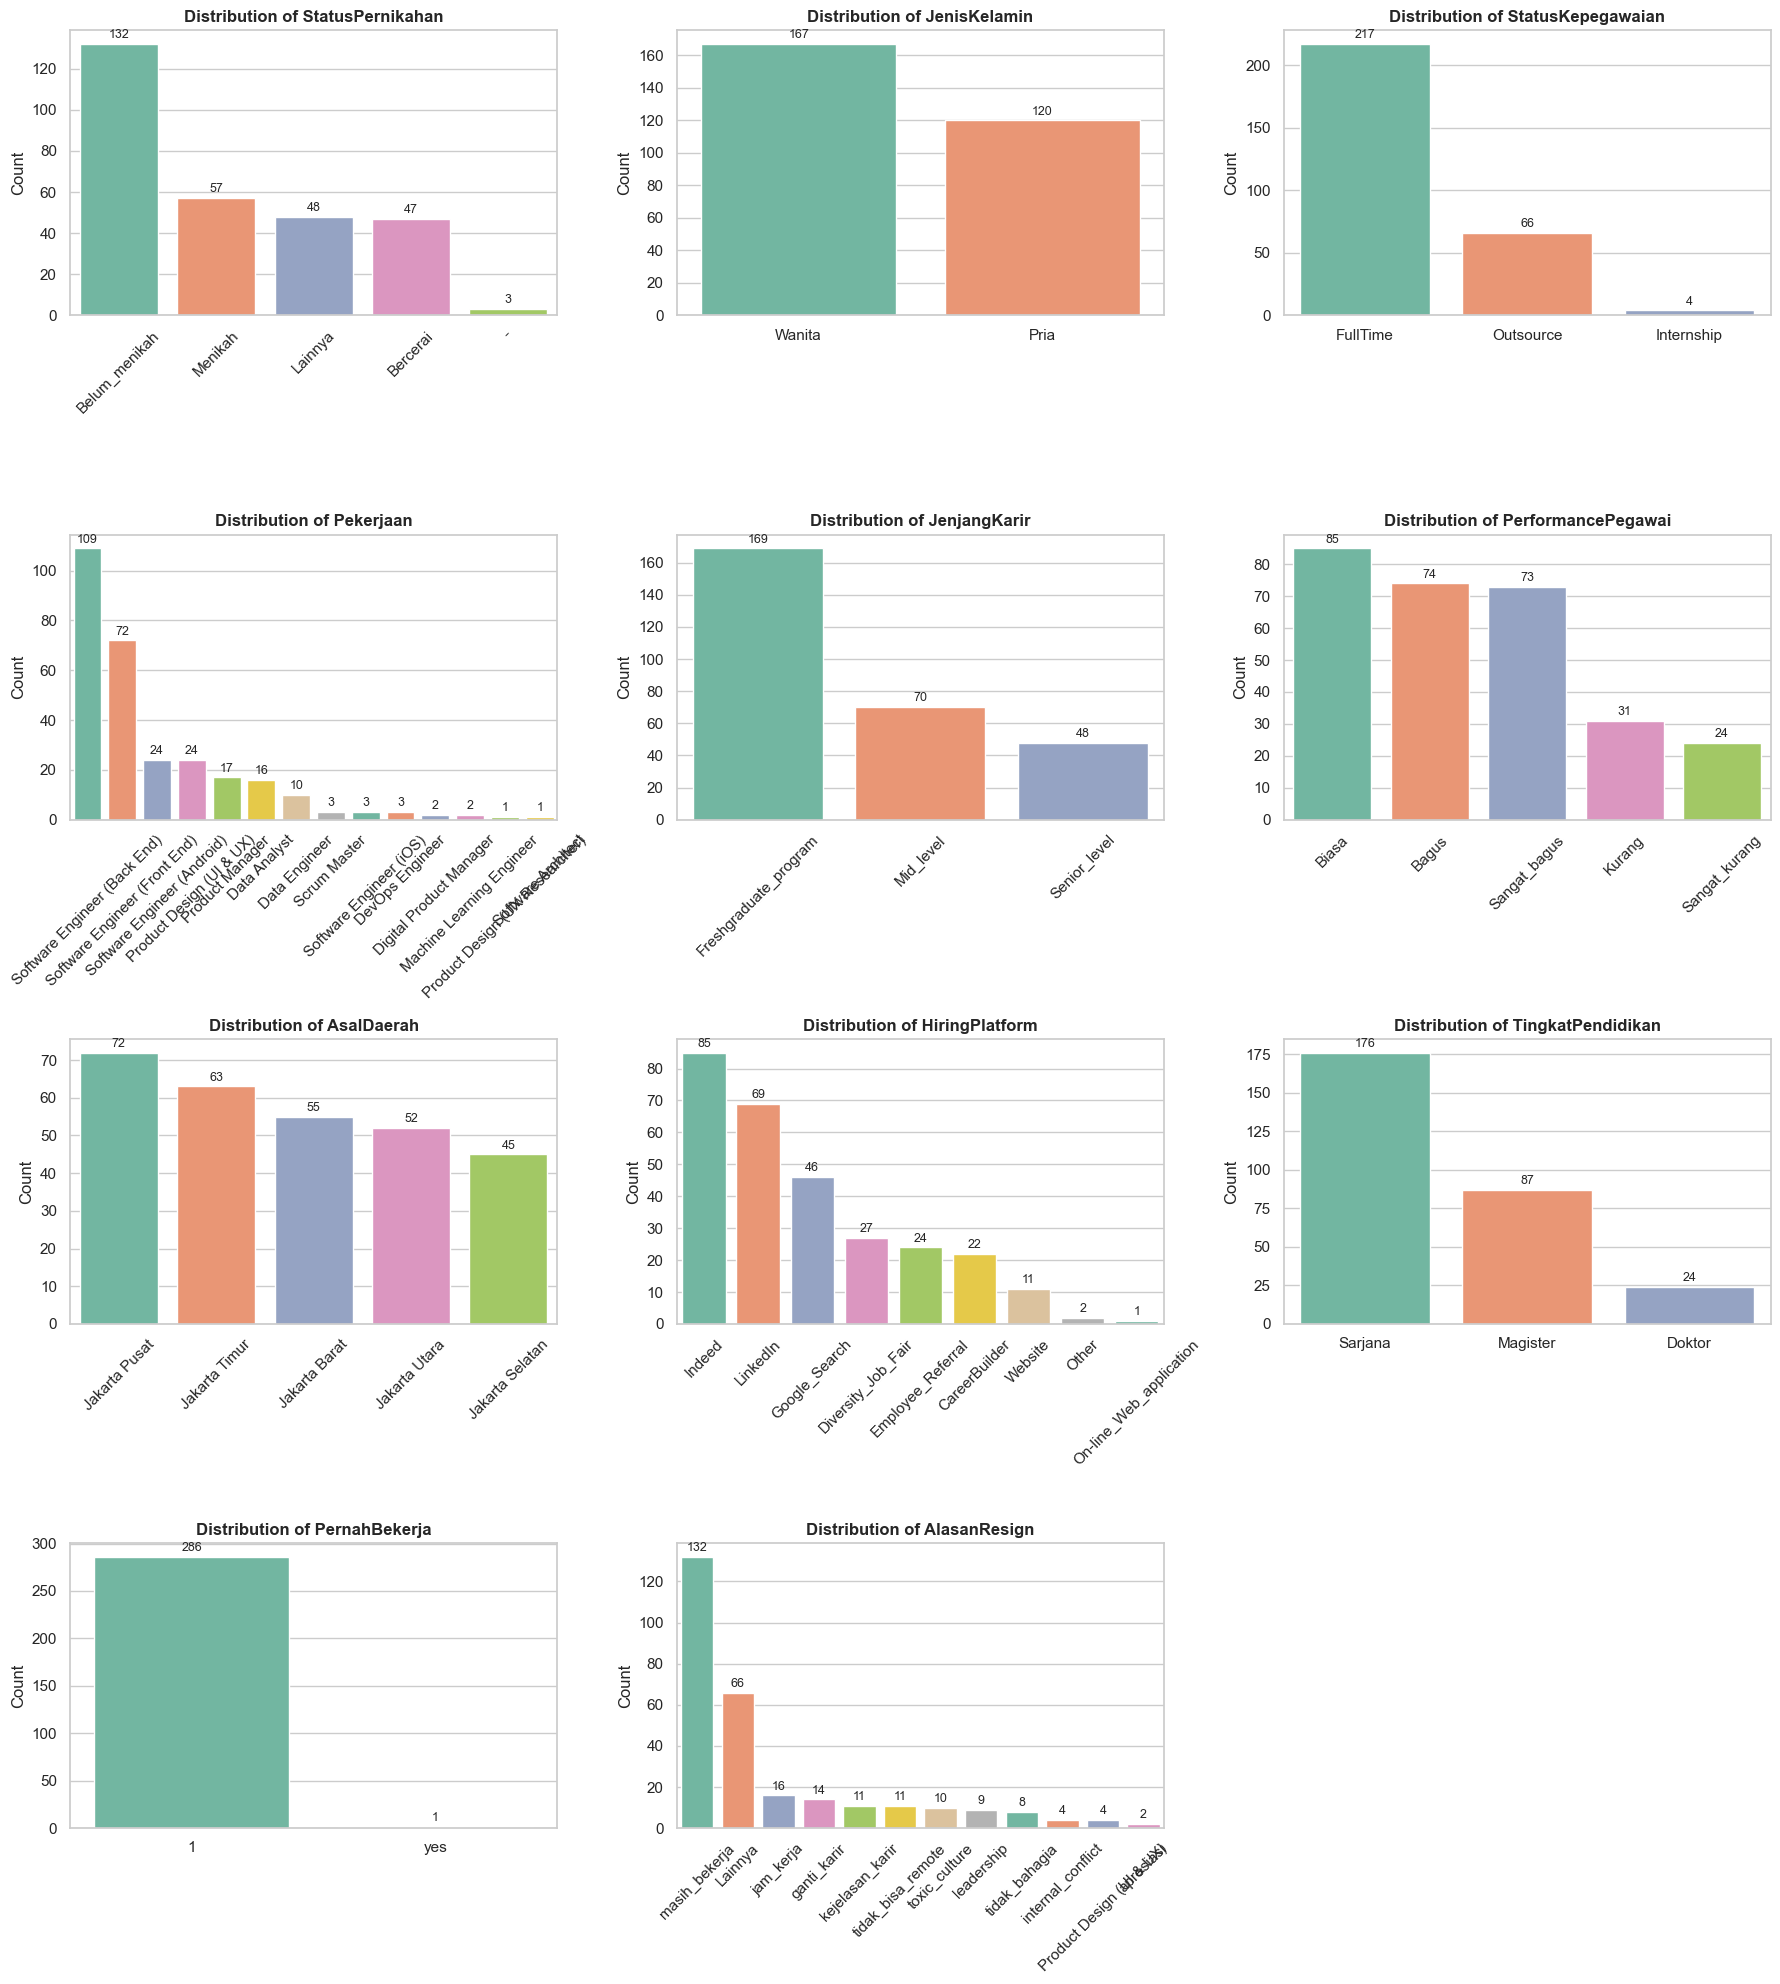

In [68]:
import math

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Automatically identify all categorical (object, category, bool) columns
categorical_cols = df01.select_dtypes(
    include=["object", "category", "bool"]
).columns

# 2. Determine grid layout (e.g., 3 columns per row)
num_cols = len(categorical_cols)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

# 3. Create subplots canvas
fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(18, 5 * rows), squeeze=False
)
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy looping

# 4. Loop through columns and plot
for i, col in enumerate(categorical_cols):
    ax = axes[i]

    # Create countplot (ordered by highest frequency)
    order = df01[col].value_counts().index
    sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)

    # Styling
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    # Add count number labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 2),
                textcoords="offset points",
            )

    # Rotate labels if there are many unique values or long string names
    if df01[col].nunique() > 4 or df01[col].astype(str).str.len().max() > 10:
        ax.tick_params(axis="x", rotation=45)

# 5. Hide any extra unused subplot slots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Handling

In [69]:
#replace
df01["StatusPernikahan"]=df01["StatusPernikahan"].replace("-", "Lainnya")

#drop
df01=df01.drop(columns="PernahBekerja")

In [70]:
df01.head(5)

,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,SkorSurveyEngagement,SkorKepuasanPegawai,JumlahKeikutsertaanProjek,JumlahKeterlambatanSebulanTerakhir,JumlahKetidakhadiran,TingkatPendidikan,IkutProgramLOP,AlasanResign,Age,LamaBekerja(Hari),Resign
0,Belum_menikah,Pria,Outsource,Software Engineer (Back End),Freshgraduate_program,Sangat_bagus,Jakarta Timur,Employee_Referral,4,4.0,0.0,0.0,9.0,Magister,1.0,masih_bekerja,48,3552,0
1,Belum_menikah,Pria,FullTime,Data Analyst,Freshgraduate_program,Sangat_kurang,Jakarta Utara,Website,4,4.0,4.0,0.0,3.0,Sarjana,1.0,toxic_culture,36,1622,1
2,Menikah,Pria,FullTime,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Timur,Indeed,4,3.0,0.0,0.0,11.0,Magister,1.0,jam_kerja,46,1353,1
3,Belum_menikah,Pria,Outsource,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Pusat,LinkedIn,3,3.0,0.0,4.0,6.0,Sarjana,0.0,masih_bekerja,41,2418,0
4,Belum_menikah,Wanita,FullTime,Product Manager,Freshgraduate_program,Bagus,Jakarta Timur,LinkedIn,3,3.0,0.0,0.0,11.0,Sarjana,0.0,ganti_karir,46,1760,1


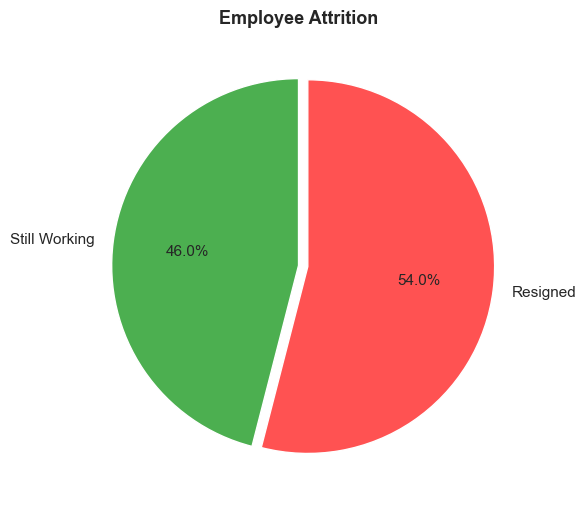

In [71]:
resign_counts = df01["Resign"].value_counts().sort_values(ascending=False)

label_map = {0: "Still Working", 1: "Resigned"}
labels = [label_map[x] for x in resign_counts.index]

color_map = {0: "#4CAF50", 1: "#FF5252"}
colors = [color_map[x] for x in resign_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    resign_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    explode=[0.05 if x == 1 else 0 for x in resign_counts.index],  # Pops out the Resigned slice
    textprops={'fontsize': 11}
)

plt.title("Employee Attrition", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Annual Report on Employee Number Changes

--- Aggregated Annual Summary Table ---
 Year  TotalJoined  TotalResigned  NetChange  ActiveEmployees
 2006            1              0          1                1
 2007            2              0          2                3
 2008            2              0          2                5
 2009            7              0          7               12
 2010            8              0          8               20
 2011           76              0         76               96
 2012           41              0         41              137
 2013           43              5         38              175
 2014           56             12         44              219
 2015           31              8         23              242
 2016           14              8          6              248
 2017            5             19        -14              234
 2018            1             26        -25              209
 2019            0              5         -5              204
 2020            0            

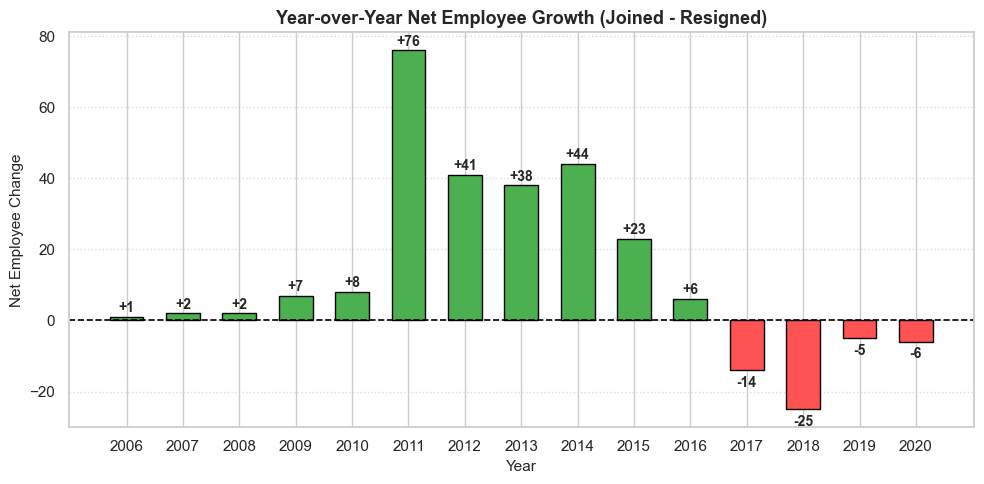

In [72]:
#Plot style
sns.set_theme(style="whitegrid")

#Cutoff date
cutoff_date = pd.Timestamp("2020-10-01")

#Ensuring date in datetime format
df["TanggalHiring"] = pd.to_datetime(df["TanggalHiring"], errors="coerce")
df["TanggalResign"] = pd.to_datetime(df["TanggalResign"], errors="coerce")

#Extract Year features
df["HiringYear"] = df["TanggalHiring"].dt.year
df["ResignYear"] = df["TanggalResign"].dt.year

# ----------------------------------------------------
# 1. Create two aggregate tables (Joined & Resigned counts)
# ----------------------------------------------------
joined_df = (
    df.groupby("HiringYear")
    .size()
    .reset_index(name="TotalJoined")
    .rename(columns={"HiringYear": "Year"})
)

resigned_df = (
    df.groupby("ResignYear")
    .size()
    .reset_index(name="TotalResigned")
    .rename(columns={"ResignYear": "Year"})
)

# ----------------------------------------------------
# 2. Join the two tables using Outer Join
# ----------------------------------------------------
summary_df = pd.merge(joined_df, resigned_df, on="Year", how="outer")

# ----------------------------------------------------
# 3. Handle missing values & sequential years up to 2020
# ----------------------------------------------------
# Convert Year column to integer, filling missing counts with 0
summary_df["TotalJoined"] = summary_df["TotalJoined"].fillna(0).astype(int)
summary_df["TotalResigned"] = summary_df["TotalResigned"].fillna(0).astype(int)

# Create a complete sequential range of years from min year up to 2020
min_year = int(summary_df["Year"].min())
max_year = cutoff_date.year  # 2020

full_years = pd.DataFrame({"Year": range(min_year, max_year + 1)})
summary_df = pd.merge(full_years, summary_df, on="Year", how="left").fillna(0)
summary_df["Year"] = summary_df["Year"].astype(int)
summary_df["TotalJoined"] = summary_df["TotalJoined"].astype(int)
summary_df["TotalResigned"] = summary_df["TotalResigned"].astype(int)

# ----------------------------------------------------
# 4. Calculate Net Change & Cumulative Active Employees
# ----------------------------------------------------
# Yearly Net Change = Total Joined in that year - Total Resigned in that year
summary_df["NetChange"] = summary_df["TotalJoined"] - summary_df["TotalResigned"]

# Cumulative Active Employees at the end of each year
summary_df["ActiveEmployees"] = summary_df["NetChange"].cumsum()

print("--- Aggregated Annual Summary Table ---")
print(summary_df.to_string(index=False))

# ----------------------------------------------------
# 5. Plot the Increases and Decreases (Yearly Net Growth)
# ----------------------------------------------------
plt.figure(figsize=(10, 5))

# Plot Net Change as a Bar Chart with color highlighting
colors = ["#4CAF50" if x >= 0 else "#FF5252" for x in summary_df["NetChange"]]
bars = plt.bar(
    summary_df["Year"],
    summary_df["NetChange"],
    color=colors,
    edgecolor="black",
    width=0.6,
)

# Add data value labels on top of/below each bar
for bar in bars:
    yval = bar.get_height()
    va_align = "bottom" if yval >= 0 else "top"
    y_pos = yval + (0.5 if yval >= 0 else -1.5)
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        y_pos,
        f"{int(yval):+d}",
        ha="center",
        va=va_align,
        fontsize=10,
        fontweight="bold",
    )

plt.axhline(0, color="black", linewidth=1.2, linestyle="--")
plt.xticks(summary_df["Year"])
plt.title(
    "Year-over-Year Net Employee Growth (Joined - Resigned)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Net Employee Change", fontsize=11)
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

# Resign Reason Analysis for Employee Attrition Management Strategy

## Step01

In [73]:
# Non-resigned employees (Resign == 0)
df_active = (
    df01[df01["Resign"] == 0]
    .groupby("Pekerjaan")
    .size()
    .reset_index(name="ActiveCount")
)

# Resigned employees (Resign == 1)
df_resigned = (
    df01[df01["Resign"] == 1]
    .groupby("Pekerjaan")
    .size()
    .reset_index(name="ResignedCount")
)

## Step02

In [74]:
df_merged = pd.merge(df_active, df_resigned, on="Pekerjaan", how="outer").fillna(0)

# Ensure count columns are integer
df_merged["ActiveCount"] = df_merged["ActiveCount"].astype(int)
df_merged["ResignedCount"] = df_merged["ResignedCount"].astype(int)

## Step03

In [75]:
df_merged["TotalEmployees"] = df_merged["ActiveCount"] + df_merged["ResignedCount"]
df_merged["PctRemaining"] = (df_merged["ActiveCount"] / df_merged["TotalEmployees"]) * 100
df_merged["PctResigned"] = (df_merged["ResignedCount"] / df_merged["TotalEmployees"]) * 100

print("--- Job Role Retention Summary ---")
print(df_merged.sort_values(by="PctRemaining", ascending=False).to_string(index=False))

--- Job Role Retention Summary ---
                     Pekerjaan  ActiveCount  ResignedCount  TotalEmployees  PctRemaining  PctResigned
                  Scrum Master            3              0               3    100.000000     0.000000
Product Design (UX Researcher)            1              0               1    100.000000     0.000000
            Software Architect            1              0               1    100.000000     0.000000
       Software Engineer (iOS)            2              1               3     66.666667    33.333333
                 Data Engineer            5              5              10     50.000000    50.000000
       Digital Product Manager            1              1               2     50.000000    50.000000
   Software Engineer (Android)           12             12              24     50.000000    50.000000
      Product Design (UI & UX)           12             12              24     50.000000    50.000000
  Software Engineer (Back End)           52    

## Step04

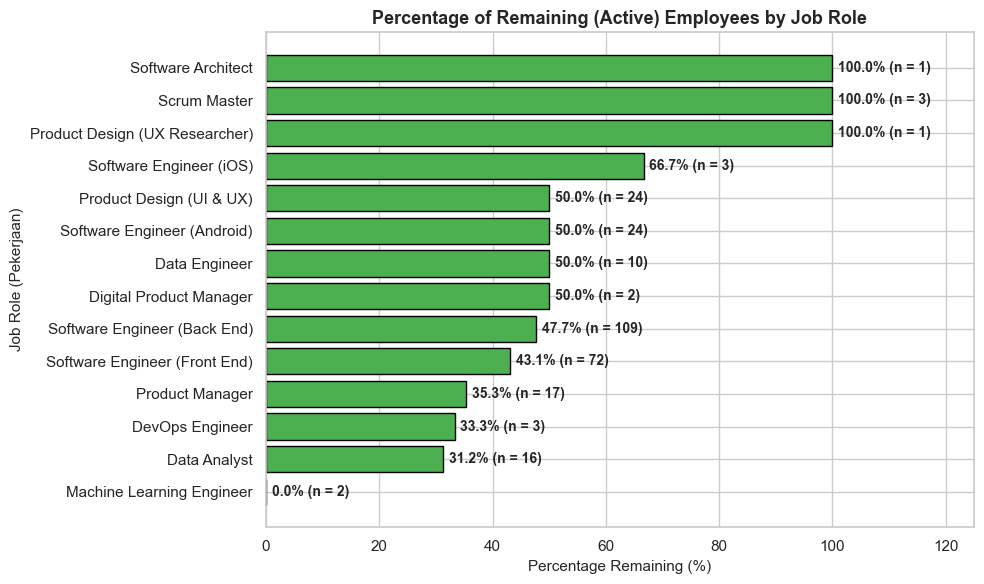

In [85]:
#visualization style
sns.set_theme(style="whitegrid")

# Sort
df_plot = df_merged.sort_values(by="PctRemaining", ascending=True)
sns.set_theme(style="whitegrid")

# Sort by percentage remaining
df_plot = df_merged.sort_values(by="PctRemaining", ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    df_plot["Pekerjaan"],
    df_plot["PctRemaining"],
    color="#4CAF50",
    edgecolor="black",
)

# Zip together the bars, total employees, and active employees for annotation
for bar, total, active in zip(
    bars, df_plot["TotalEmployees"], df_plot["ActiveCount"]
):
    width = bar.get_width()

    # Format string to display percentage and total count n
    label = f"{width:.1f}% (n = {total})"

    plt.text(
        width + 1,  # Offset to place text just outside the bar
        bar.get_y() + bar.get_height() / 2.0,
        label,
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
    )

plt.title(
    "Percentage of Remaining (Active) Employees by Job Role",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Percentage Remaining (%)", fontsize=11)
plt.ylabel("Job Role (Pekerjaan)", fontsize=11)
plt.xlim(0, 125)  # Expanded x-limit to prevent text cutoff
plt.tight_layout()
plt.show()

## Step05

In [86]:
#Division with Highest Resignation Rate & Aggregate by Career Level, Performance, and Resign Reason

# Define target job role directly
target_division = "Software Engineer (Back End)"
print(f"\n[INFO] Analyzing Resignation Breakdown for: {target_division}")

# Filter resigned employees for Software Engineer (Back End)
df_target = df01[(df01["Pekerjaan"] == target_division) & (df01["Resign"] == 1)]

# Aggregation table by Career Level, Performance, and Resign Reason
agg_target = (
    df_target.groupby(["JenjangKarir", "PerformancePegawai", "AlasanResign"])
    .size()
    .reset_index(name="ResignedCount")
    .sort_values(by="ResignedCount", ascending=False)
)

print(f"\n--- Resignation Breakdown for {target_division} ---")
print(agg_target.to_string(index=False))


[INFO] Analyzing Resignation Breakdown for: Software Engineer (Back End)

--- Resignation Breakdown for Software Engineer (Back End) ---
         JenjangKarir PerformancePegawai             AlasanResign  ResignedCount
Freshgraduate_program              Biasa                  Lainnya              5
         Senior_level              Biasa                  Lainnya              5
Freshgraduate_program              Bagus                  Lainnya              4
Freshgraduate_program       Sangat_bagus                  Lainnya              4
         Senior_level              Bagus                  Lainnya              2
            Mid_level       Sangat_bagus                jam_kerja              2
Freshgraduate_program             Kurang                  Lainnya              2
Freshgraduate_program       Sangat_bagus        tidak_bisa_remote              2
Freshgraduate_program      Sangat_kurang                  Lainnya              2
            Mid_level              Biasa            

## Step06

<Figure size 1200x600 with 0 Axes>

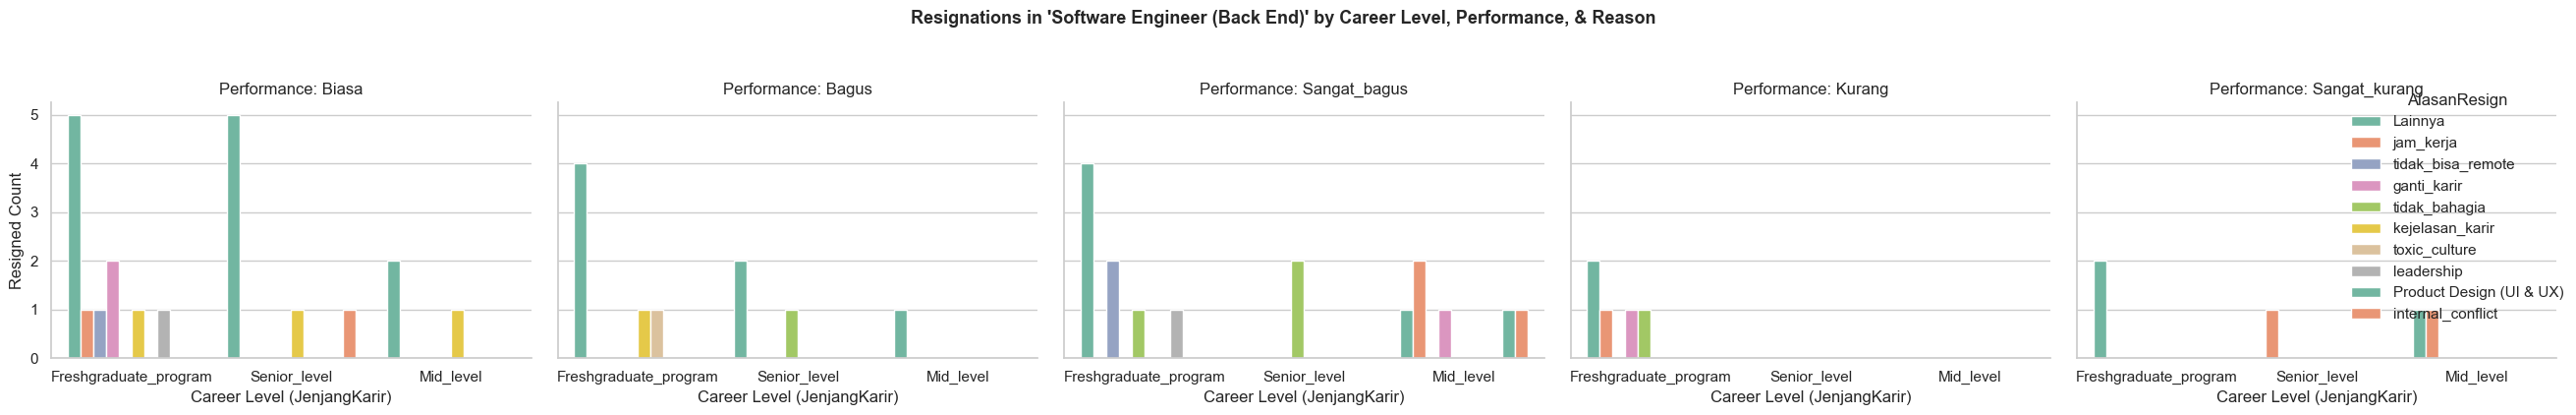

In [88]:
plt.figure(figsize=(12, 6))
chart = sns.catplot(
    data=agg_target,
    x="JenjangKarir",
    y="ResignedCount",
    hue="AlasanResign",
    col="PerformancePegawai",
    kind="bar",
    palette="Set2",
    height=4,
    aspect=1.2,
)

chart.fig.suptitle(
    f"Resignations in '{target_division}' by Career Level, Performance, & Reason",
    y=1.05,
    fontsize=13,
    fontweight="bold",
)
chart.set_axis_labels("Career Level (JenjangKarir)", "Resigned Count")
chart.set_titles("Performance: {col_name}")

plt.tight_layout()
plt.show()

# COBA_COBA/TEST_dRIVE

In [94]:
# Save DataFrame to Excel
df01.to_csv("NEWDATA.csv", index=False)

In [80]:
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   StatusPernikahan                    287 non-null    str    
 1   JenisKelamin                        287 non-null    str    
 2   StatusKepegawaian                   287 non-null    str    
 3   Pekerjaan                           287 non-null    str    
 4   JenjangKarir                        287 non-null    str    
 5   PerformancePegawai                  287 non-null    str    
 6   AsalDaerah                          287 non-null    str    
 7   HiringPlatform                      287 non-null    str    
 8   SkorSurveyEngagement                287 non-null    int64  
 9   SkorKepuasanPegawai                 287 non-null    float64
 10  JumlahKeikutsertaanProjek           284 non-null    float64
 11  JumlahKeterlambatanSebulanTerakhir  287 non-null    floa

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_8052\2742107547.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df01.select_dtypes(
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_8052\2742107547.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_8052\2742107547.py:26: FutureWarning: 



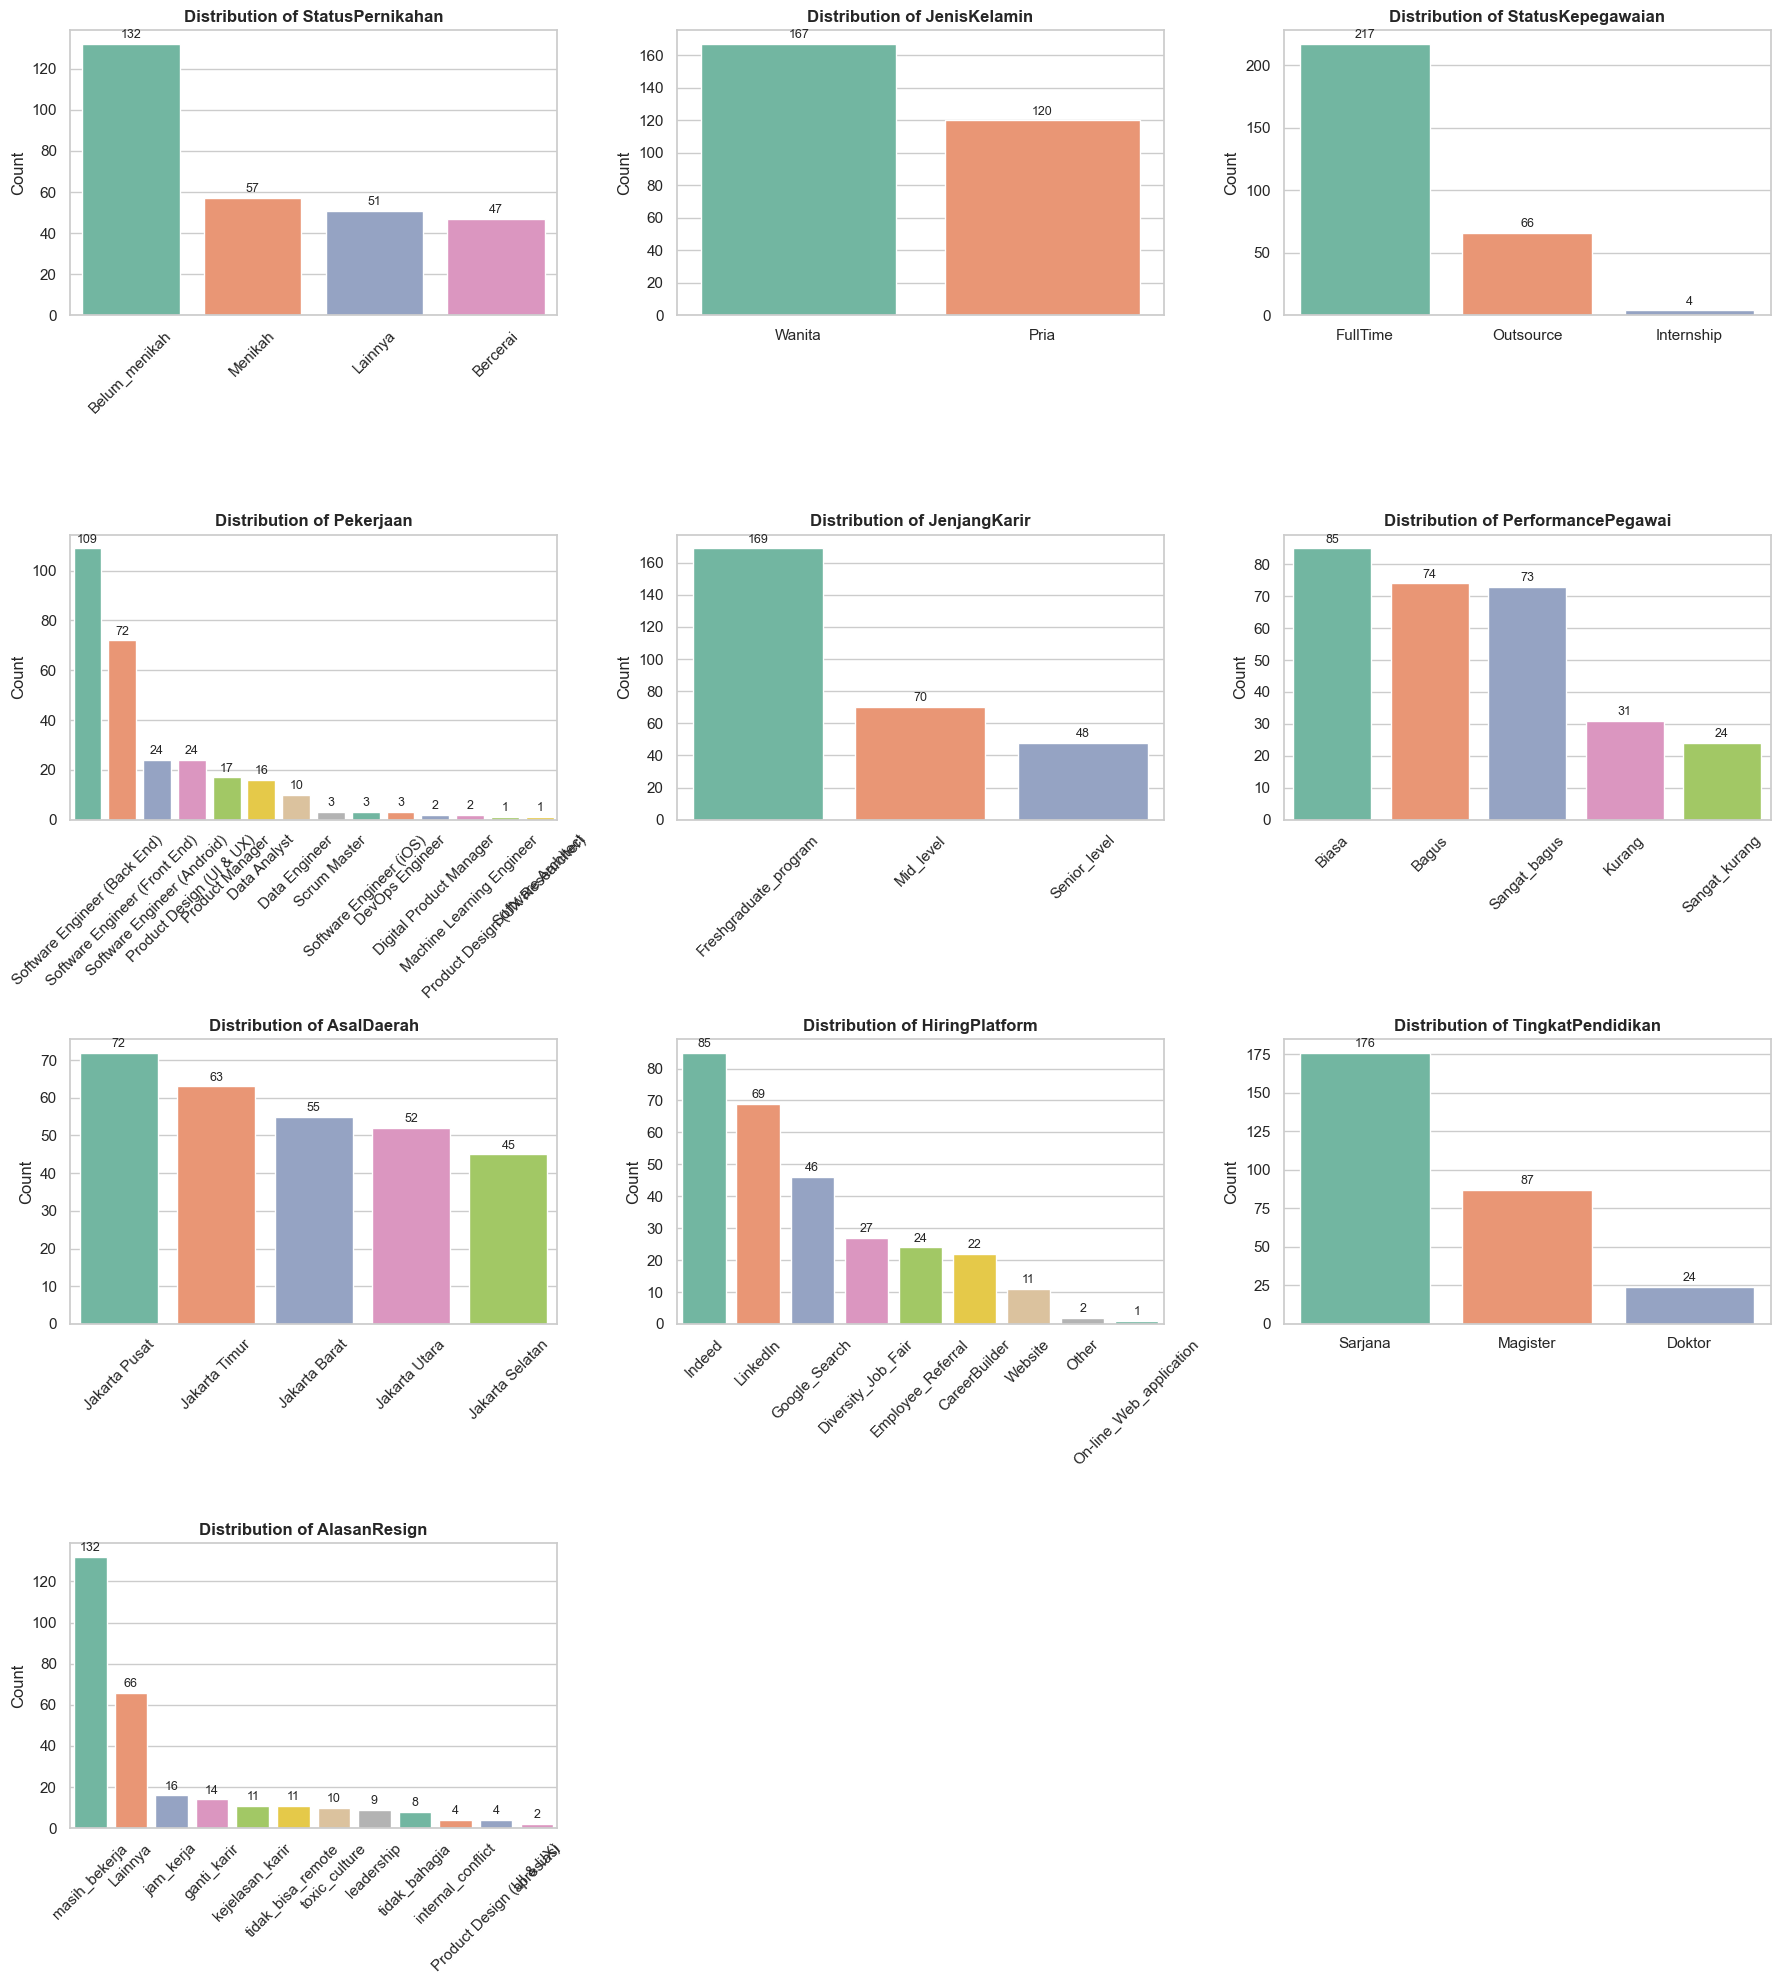

In [81]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Automatically identify all categorical (object, category, bool) columns
categorical_cols = df01.select_dtypes(
    include=["object", "category", "bool"]
).columns

# 2. Determine grid layout (e.g., 3 columns per row)
num_cols = len(categorical_cols)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

# 3. Create subplots canvas
fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(18, 5 * rows), squeeze=False
)
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy looping

# 4. Loop through columns and plot
for i, col in enumerate(categorical_cols):
    ax = axes[i]

    # Create countplot (ordered by highest frequency)
    order = df01[col].value_counts().index
    sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)

    # Styling
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    # Add count number labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 2),
                textcoords="offset points",
            )

    # Rotate labels if there are many unique values or long string names
    if df01[col].nunique() > 4 or df01[col].astype(str).str.len().max() > 10:
        ax.tick_params(axis="x", rotation=45)

# 5. Hide any extra unused subplot slots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

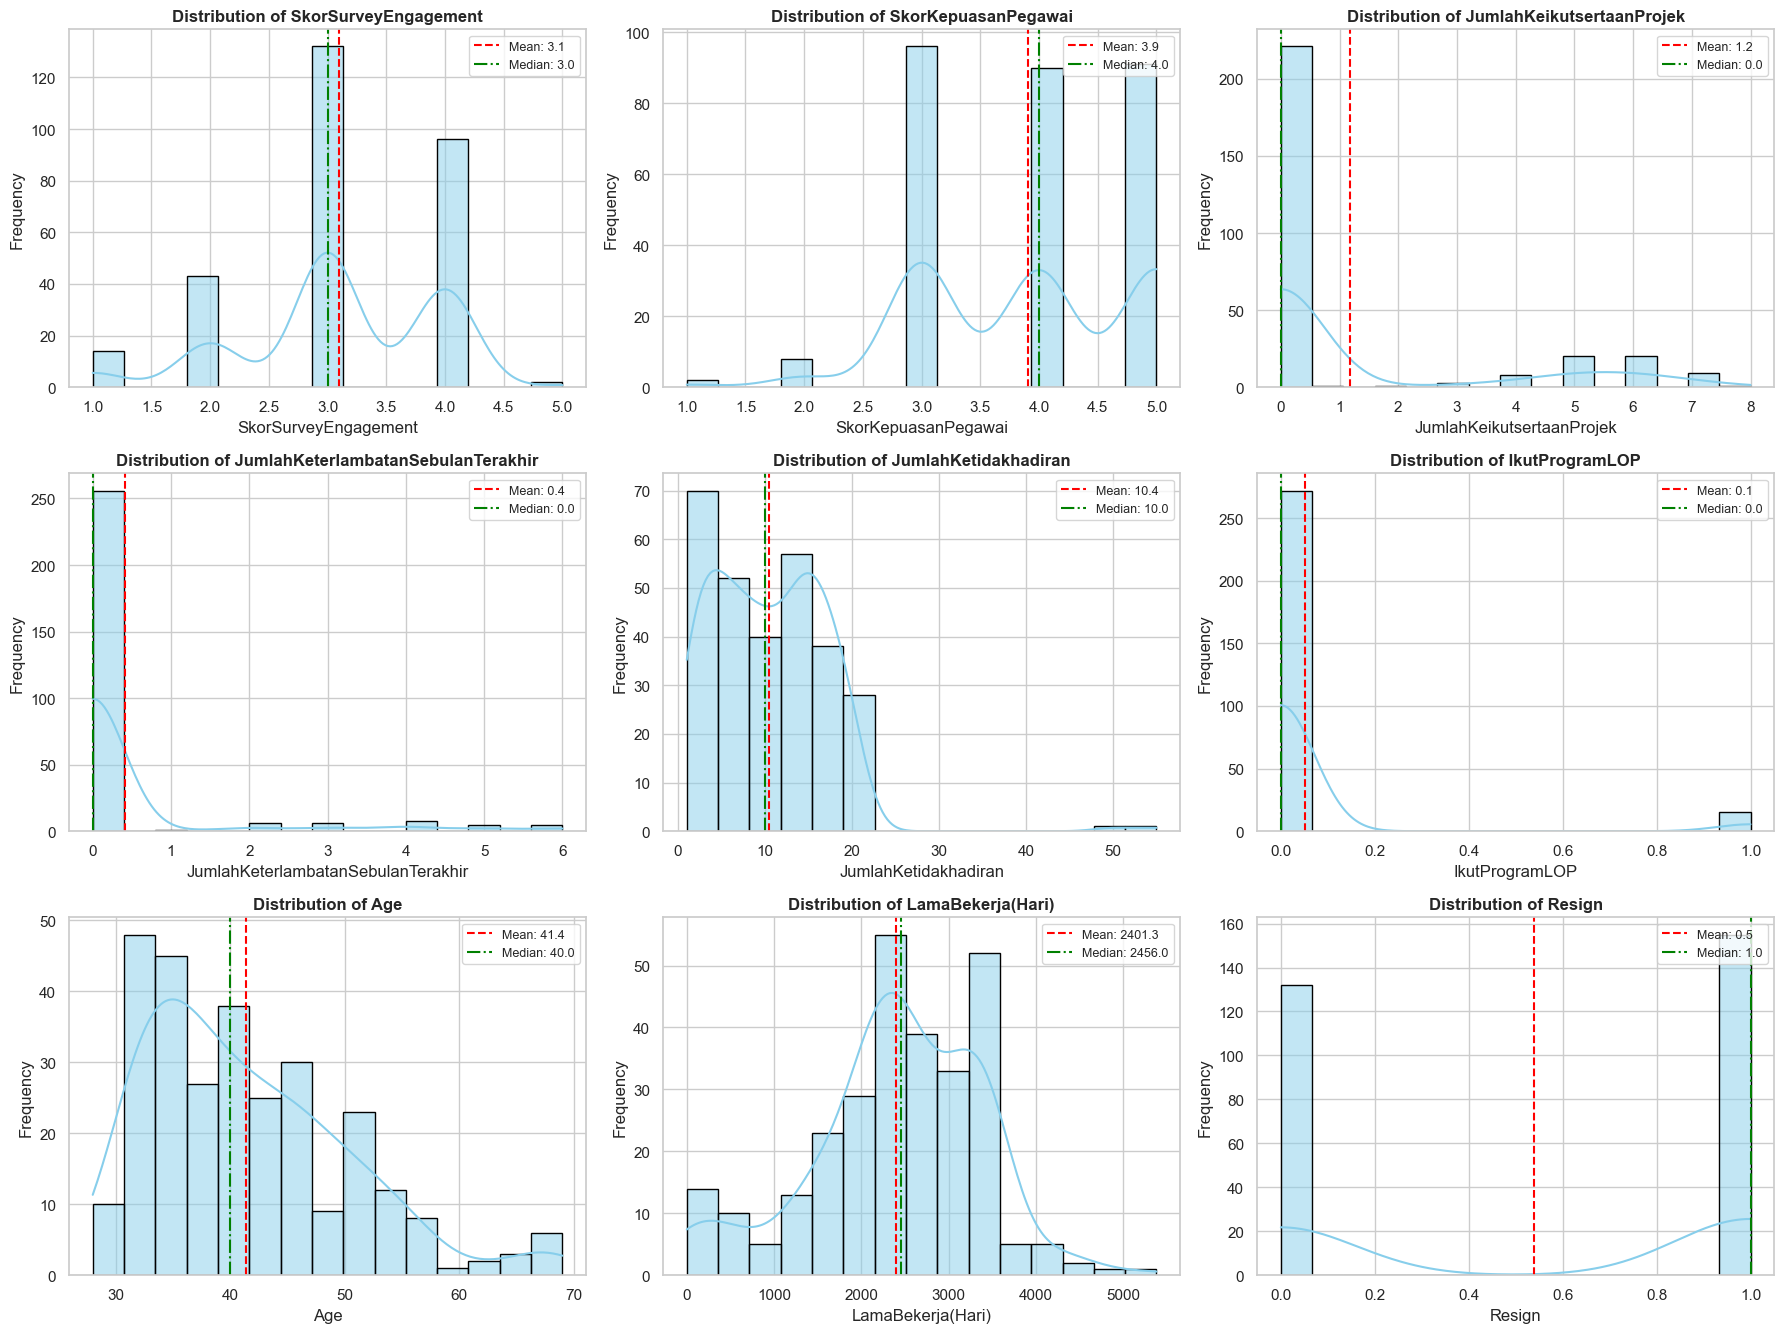

In [82]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Automatically identify all numerical (int, float) columns
numerical_cols = df01.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns

# 2. Determine grid layout (3 columns per row)
num_cols = len(numerical_cols)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

# 3. Create subplots canvas
fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(18, 4.5 * rows), squeeze=False
)
axes = axes.flatten()  # Flatten 2D array into 1D for easy looping

# 4. Loop through numerical columns and plot histograms
for i, col in enumerate(numerical_cols):
    ax = axes[i]

    # Create histogram with KDE overlay
    sns.histplot(
        data=df01,
        x=col,
        kde=True,
        color="skyblue",
        edgecolor="black",
        bins=15,
        ax=ax,
    )

    # Calculate mean and median for visual reference
    mean_val = df01[col].mean()
    median_val = df01[col].median()

    # Add vertical dashed lines for mean (red) and median (green)
    ax.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean: {mean_val:.1f}",
    )
    ax.axvline(
        median_val,
        color="green",
        linestyle="-.",
        linewidth=1.5,
        label=f"Median: {median_val:.1f}",
    )

    # Styling
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9, loc="upper right")

# 5. Hide any unused subplot slots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

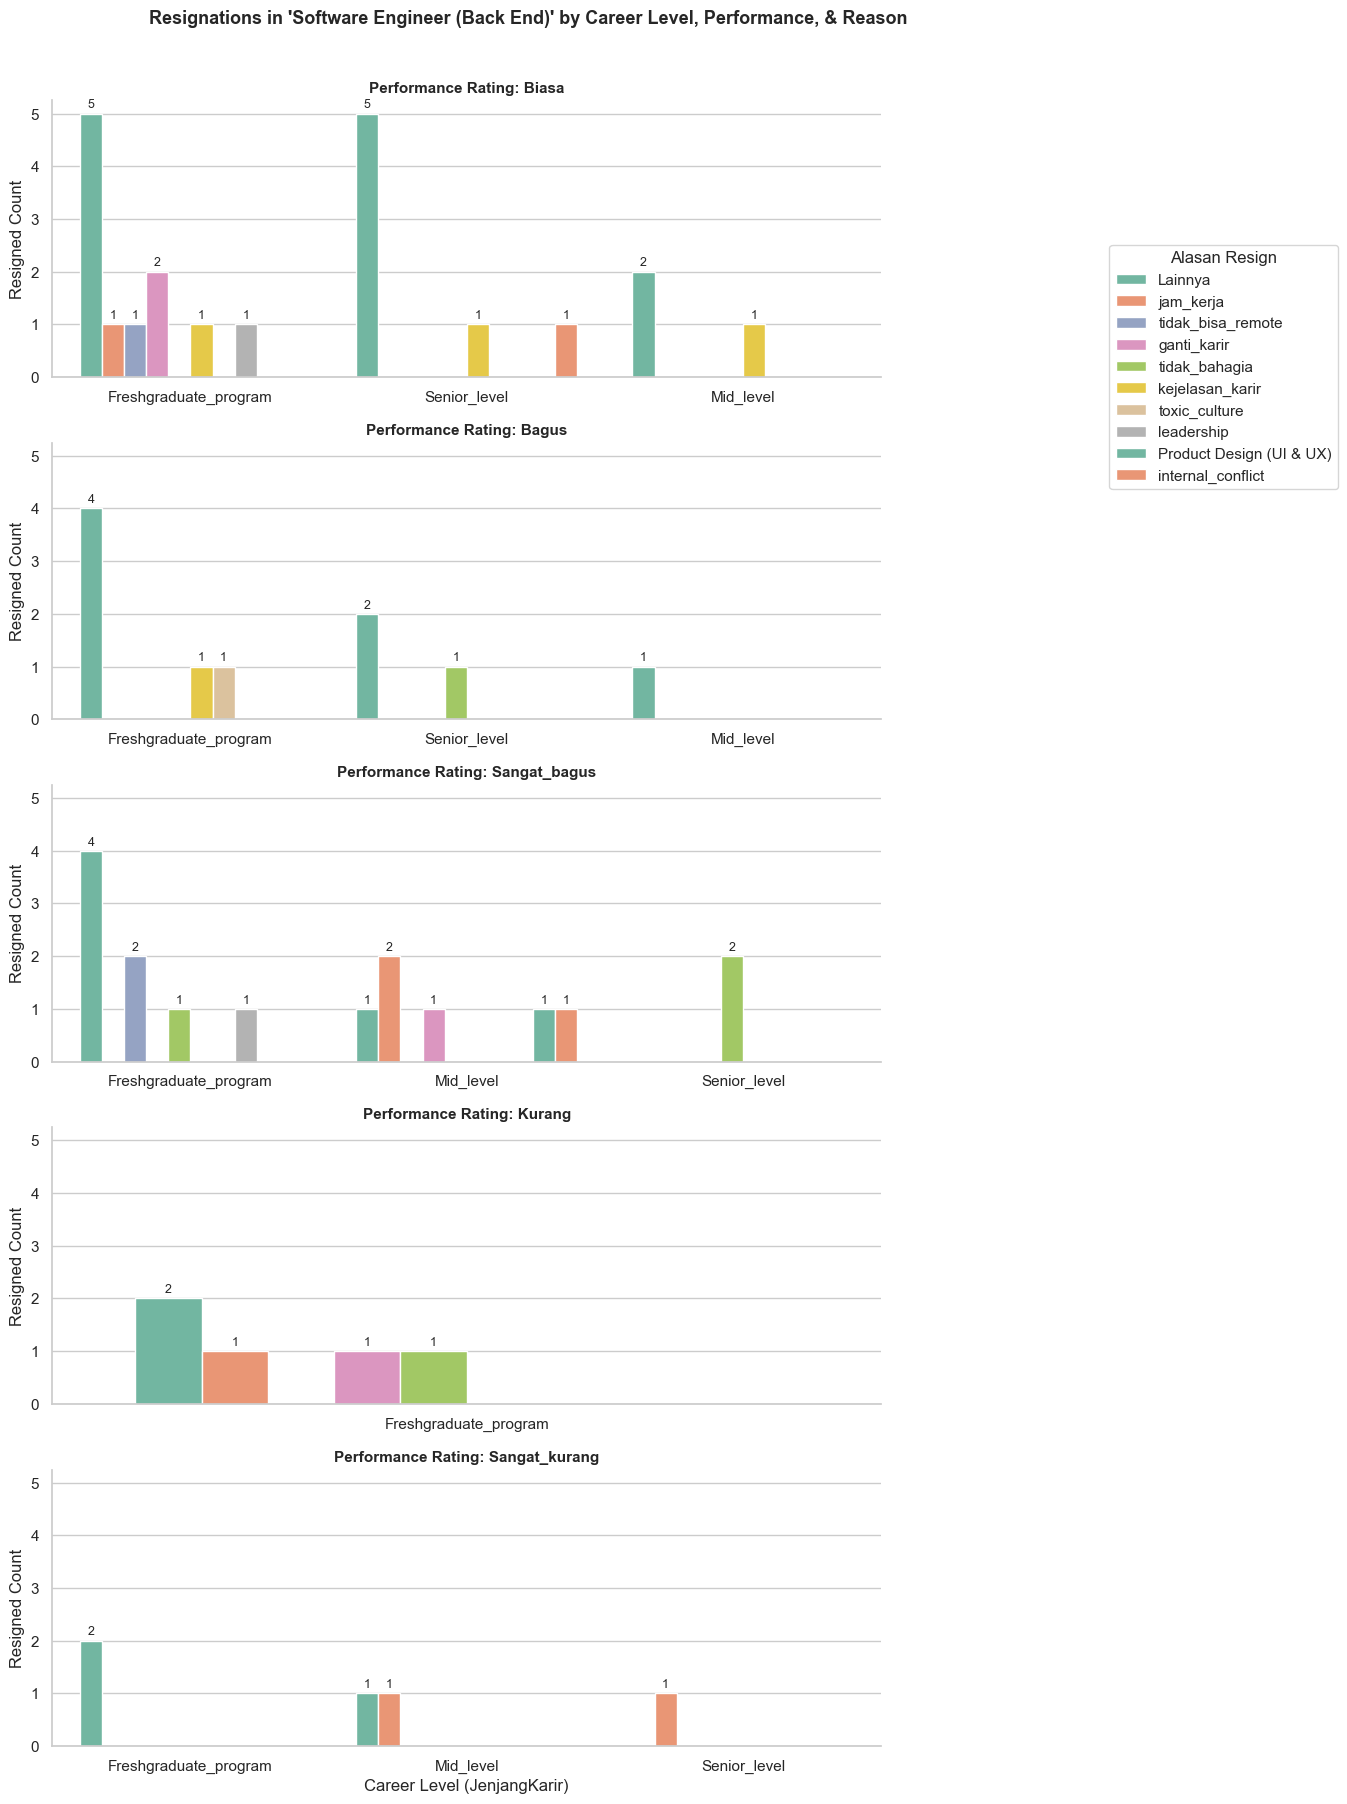

In [ ]:
sns.set_theme(style="whitegrid")

# Create vertical facets
chart = sns.catplot(
    data=agg_target,
    x="JenjangKarir",
    y="ResignedCount",
    hue="AlasanResign",
    col="PerformancePegawai",
    col_wrap=1,  # Stack vertically
    kind="bar",
    palette="Set2",
    height=3.5,
    aspect=2.5,
    sharex=False,  # Keep career levels visible on all subplots
)

# Set titles and axis labels
chart.fig.suptitle(
    f"Resignations in '{target_division}' by Career Level, Performance, & Reason",
    y=1.03,
    fontsize=13,
    fontweight="bold",
)
chart.set_axis_labels("Career Level (JenjangKarir)", "Resigned Count")
chart.set_titles("Performance Rating: {col_name}", size=11, weight="bold")

# Move legend outside the plot area to the right
sns.move_legend(
    chart,
    loc="upper left",
    bbox_to_anchor=(1.02, 0.9),  # Places legend cleanly to the right
    title="Alasan Resign",
    frameon=True,
)

# Iterate through subplots to format ticks and bar labels
for ax in chart.axes.flat:
    ax.tick_params(labelbottom=True)  # Keep JenjangKarir visible

    # Add count numbers on top of bars
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 2),
                textcoords="offset points",
            )

# Adjust layout to make room for the right legend
plt.subplots_adjust(right=0.82)
plt.show()